<a href="https://colab.research.google.com/github/uavinash15/DataScience-/blob/main/Notebooks/Multiple%20Linear%20Regression/MULTIPLE_LINEAR_REGRESSION_IPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MULTIPLE LINEAR REGRESSION**

# **Predicting the SOLD PRICE (Auction Price) of Players**

# **Developing Multiple Linear Regression Model Using Python**

**Loading the Dataset**

In [ ]:
import pandas as pd

In [ ]:
ipl_auction_df=pd.read_csv('IPL IMB381IPL2013.csv')

In [ ]:
ipl_auction_df

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00,...,0.00,0,307,15,20.47,8.90,13.93,2009,50000,50000
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41,...,0.00,0,29,0,0.00,14.50,0.00,2008,50000,50000
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62,...,121.01,5,1059,29,36.52,8.81,24.90,2008,200000,350000
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56,...,76.32,0,1125,49,22.96,6.23,22.14,2011,100000,850000
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93,...,120.71,28,0,0,0.00,0.00,0.00,2011,100000,800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,126,"Yadav, AS",2,IND,DC,Batsman,0,0,0,0.00,...,125.64,2,0,0,0.00,0.00,0.00,2010,50000,750000
126,127,Younis Khan,2,PAK,RR,Batsman,6398,7,6814,75.78,...,42.85,0,0,0,0.00,0.00,0.00,2008,225000,225000
127,128,Yuvraj Singh,2,IND,KXIP+,Batsman,1775,9,8051,87.58,...,131.88,67,569,23,24.74,7.02,21.13,2011,400000,1800000
128,129,Zaheer Khan,2,IND,MI+,Bowler,1114,288,790,73.55,...,91.67,1,1783,65,27.43,7.75,21.26,2008,200000,450000


In [ ]:
ipl_auction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

**Displaying the First Five Records**

In [ ]:
ipl_auction_df.iloc[0:5,0:10]

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93


In [ ]:
X_features=ipl_auction_df.columns

In [ ]:
#X_features

In [ ]:
#ipl_auction_df[X_features]

In [ ]:
X_features=[ 'AGE','COUNTRY','PLAYING ROLE','T-RUNS','T-WKTS','ODI-RUNS-S',
            'ODI-SR-B','ODI-WKTS','ODI-SR-BL','CAPTAINCY EXP','RUNS-S','HS',
             'AVE','SR-B','SIXERS','RUNS-C','WKTS','AVE-BL','ECON','SR-BL']

In [ ]:
#ipl_auction_df[X_features]

# **Encoding Categorical Features**

In [ ]:
#ipl_auction_df['PLAYING ROLE']

In [ ]:
ipl_auction_df['PLAYING ROLE'].unique()

array(['Allrounder', 'Bowler', 'Batsman', 'W. Keeper'], dtype=object)

In [ ]:
pd.get_dummies(ipl_auction_df['PLAYING ROLE'])[0:5]

,Allrounder,Batsman,Bowler,W. Keeper
0,True,False,False,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,True,False,False


In [ ]:
pd.get_dummies(ipl_auction_df['PLAYING ROLE'])[0:5].astype(int)

,Allrounder,Batsman,Bowler,W. Keeper
0,1,0,0,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,1,0,0


In [ ]:
categorical_features=['AGE','COUNTRY','PLAYING ROLE','CAPTAINCY EXP']

In [ ]:
#ipl_auction_df[X_features]

In [ ]:
ipl_auction_encoded_df=pd.get_dummies(ipl_auction_df[X_features],
                                      columns=categorical_features,
                                      drop_first=True).astype(int)  # this function deletes one of the data from the AGE(i.e 0),COUNTRY(i.e SA), PLAYING ROLE( i.e Allrounder), CAPTAINCY EXP(ie.0)

In [ ]:
#ipl_auction_encoded_df.head()

In [ ]:
ipl_auction_encoded_df.columns

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AGE_2', 'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG',
       'COUNTRY_IND', 'COUNTRY_NZ', 'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL',
       'COUNTRY_WI', 'COUNTRY_ZIM', 'PLAYING ROLE_Batsman',
       'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
      dtype='object')

In [ ]:
#X_features

In [ ]:
X_features=ipl_auction_encoded_df.columns

In [ ]:
X_features

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AGE_2', 'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG',
       'COUNTRY_IND', 'COUNTRY_NZ', 'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL',
       'COUNTRY_WI', 'COUNTRY_ZIM', 'PLAYING ROLE_Batsman',
       'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
      dtype='object')

# **Splitting the Dataset into Train and Validation Sets**

In [ ]:
import statsmodels.api as sm

In [ ]:
X= sm.add_constant(ipl_auction_encoded_df) # adding constant values 1 to all the data with const column
Y=ipl_auction_df['SOLD PRICE']

In [ ]:
#X

In [ ]:
#Y

In [ ]:
#X.head()

In [ ]:
#Y.head()

In [ ]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_Y,test_Y=train_test_split(X,Y,train_size=0.8,random_state=42)

In [ ]:
#train_Y.astype(int)

In [ ]:
#train_X.head()

In [ ]:
#train_X.count() #80% of 130= 104

In [ ]:
#test_X.head()

In [ ]:
#test_X.count()

In [ ]:
#train_Y.head()

In [ ]:
#train_Y.count()

In [ ]:
#test_Y.head()

In [ ]:
#test_Y.count()

# **Building the Model on the Training Dataset**

In [ ]:
ipl_model_l=sm.OLS(train_Y,train_X).fit()
ipl_model_l.summary2() #.summary2() is used rather than summary() because it gives larger data and helps to find out multicollinearity

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Ordinary least squares
========================================================================================
Model:                     OLS                     Adj. R-squared:            0.364     
Dependent Variable:        SOLD PRICE              AIC:                       2964.8676 
Date:                      2025-11-21 14:09        BIC:                       3049.4881 
No. Observations:          104                     Log-Likelihood:            -1450.4   
Df Model:                  31                      F-statistic:               2.904     
Df Residuals:              72                      Prob (F-statistic):        0.000103  
R-squared:                 0.556                   Scale:                     1.0990e+11
----------------------------------------------------------------------------------------
                          Coef.       Std.Err.     t    P>|t|     [0.025       0.975]   
----------------------------------------------------------------------------------------
const                   372659.1870 227434.2708  1.6385 0.1057  -80722.7456  826041.1196
T-RUNS                     -52.3888     32.6499 -1.6046 0.1130    -117.4751      12.6975
T-WKTS                    -111.0099    609.1010 -0.1823 0.8559   -1325.2305    1103.2107
ODI-RUNS-S                  57.5472     31.4611  1.8292 0.0715      -5.1694     120.2638
ODI-SR-B                  -507.6748   1576.0642 -0.3221 0.7483   -3649.5013    2634.1518
ODI-WKTS                   785.7553    829.5857  0.9472 0.3467    -867.9936    2439.5041
ODI-SR-BL                 -800.5354   1535.7799 -0.5213 0.6038   -3862.0566    2260.9858
RUNS-S                     111.9832    172.9037  0.6477 0.5193    -232.6940     456.6604
HS                       -5623.1814   2582.9130 -2.1771 0.0328  -10772.1243    -474.2385
AVE                      22000.9765   7772.2768  2.8307 0.0060    6507.2258   37494.7272
SR-B                     -1317.3506   1366.2137 -0.9642 0.3382   -4040.8479    1406.1466
SIXERS                    4330.7634   4081.1760  1.0612 0.2922   -3804.9122   12466.4390
RUNS-C                      63.2961    297.5020  0.2128 0.8321    -529.7632     656.3554
WKTS                      3320.9611   7260.0208  0.4574 0.6487  -11151.6258   17793.5481
AVE-BL                    4068.6464  10102.8277  0.4027 0.6883  -16070.9726   24208.2654
ECON                     -8322.2586  12997.2187 -0.6403 0.5240  -34231.7404   17587.2233
SR-BL                    -5723.0804  13855.0110 -0.4131 0.6808  -33342.5400   21896.3792
AGE_2                  -227379.0287 113760.8021 -1.9987 0.0494 -454157.0429    -601.0145
AGE_3                  -214947.2649 152021.3599 -1.4139 0.1617 -517996.3072   88101.7774
COUNTRY_BAN             -94939.8648 437698.6503 -0.2169 0.8289 -967476.1774  777596.4477
COUNTRY_ENG             661489.9061 237606.1666  2.7840 0.0069  187830.6698 1135149.1425
COUNTRY_IND             158549.8025 126387.5248  1.2545 0.2137  -93399.1235  410498.7284
COUNTRY_NZ              202111.4119 173652.8262  1.1639 0.2483 -144059.1704  548281.9942
COUNTRY_PAK              84452.7198 193553.6344  0.4363 0.6639 -301389.3987  470294.8382
COUNTRY_SA               57750.2131 144542.2005  0.3995 0.6907 -230389.3974  345889.8235
COUNTRY_SL               20044.9921 175917.8867  0.1139 0.9096 -330640.9057  370730.8899
COUNTRY_WI                6359.2147 229993.7793  0.0276 0.9780 -452125.0049  464843.4342
COUNTRY_ZIM            -140530.8519 401096.4495 -0.3504 0.7271 -940102.0106  659040.3068
PLAYING ROLE_Batsman     79302.5819 149573.8530  0.5302 0.5976 -218867.4446  377472.6085
PLAYING ROLE_Bowler      10036.6107 125895.4548  0.0797 0.9367 -240931.3916  261004.6130
PLAYING ROLE_W. Keeper  -71971.1812 212430.8452 -0.3388 0.7357 -495444.3316  351501.9693
CAPTAINCY EXP_1         161764.7151 123273.7283  1.3122 0.1936  -83976.9709  407506.4012
----------------------------------------------------------------

# **Multi-Collinearity and Handling Multi-Collinearity**

In [ ]:
import numpy as np

In [ ]:
#X

In [ ]:
#X_matrix=X.values
#print(np.round(X_matrix,3))

In [ ]:
#X_matrix.shape[1]

In [ ]:
#for i in range(X_matrix.shape[1]):
  #print(i)

In [ ]:
#variance_inflation_factor(X_matrix,0)

In [ ]:
#variance_inflation_factor(X_matrix,1)

In [ ]:
#X

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def get_vif_factors(X):
  X_matrix=X.values
  vif=[variance_inflation_factor(X_matrix,i) for  i in range(X_matrix.shape[1])] #X_matrix.shape[1] =32
  vif_factors=pd.DataFrame()
  vif_factors['column']=X.columns
  vif_factors['VIF']=vif

  return vif_factors

In [ ]:
#X_features #columns of original df

In [ ]:
#X

In [ ]:
[X_features]

[Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
        'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
        'ECON', 'SR-BL', 'AGE_2', 'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG',
        'COUNTRY_IND', 'COUNTRY_NZ', 'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL',
        'COUNTRY_WI', 'COUNTRY_ZIM', 'PLAYING ROLE_Batsman',
        'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
       dtype='object')]

In [ ]:
#X_matrix=X[X_features].values
#X_matrix

In [ ]:
#print(X_matrix.shape)

In [ ]:
#X_matrix.shape[1]

In [ ]:
#X_matrix

In [ ]:
#variance_inflation_factor(X_matrix,2)

In [ ]:
vif_factors=get_vif_factors(X[X_features])
vif_factors

,column,VIF
0,T-RUNS,12.608139
1,T-WKTS,7.681507
2,ODI-RUNS-S,16.419787
3,ODI-SR-B,13.698329
4,ODI-WKTS,9.942222
5,ODI-SR-BL,4.390192
6,RUNS-S,16.096917
7,HS,22.817054
8,AVE,24.462160
9,SR-B,21.274607


**Checking Correlation of Columns with Large VIFs**

In [ ]:
columns_with_large_vif=vif_factors[vif_factors.VIF>4].column

In [ ]:
#columns_with_large_vif

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt

In [ ]:
#X[columns_with_large_vif].corr()

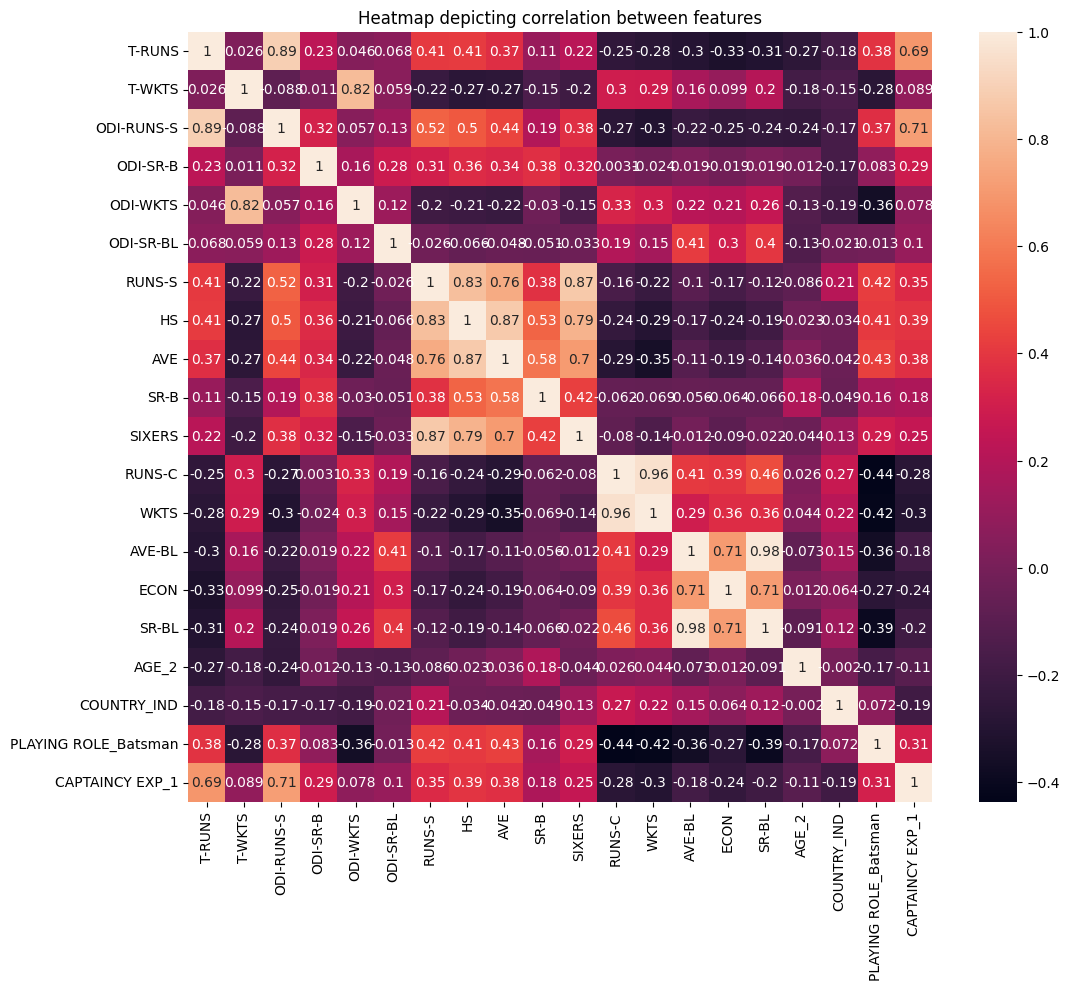

In [ ]:
plt.figure(figsize=(12,10))
sn.heatmap(X[columns_with_large_vif].corr(),annot=True)
plt.title("Heatmap depicting correlation between features")
plt.show()

In [ ]:
columns_to_be_removed=['T-RUNS','T-WKTS','RUNS-S','HS','AVE','RUNS-C','SR-B',
                       'AVE-BL','ECON','ODI-SR-B','ODI-RUNS-S','AGE_2','SR-BL']

In [ ]:
#X_features

In [ ]:
X_new_features=list(set(X_features)-set(columns_to_be_removed))

In [ ]:
X_new_features

['COUNTRY_SL',
 'PLAYING ROLE_Batsman',
 'AGE_3',
 'COUNTRY_BAN',
 'COUNTRY_ENG',
 'PLAYING ROLE_Bowler',
 'COUNTRY_NZ',
 'COUNTRY_ZIM',
 'SIXERS',
 'PLAYING ROLE_W. Keeper',
 'COUNTRY_PAK',
 'ODI-WKTS',
 'COUNTRY_WI',
 'COUNTRY_IND',
 'ODI-SR-BL',
 'WKTS',
 'CAPTAINCY EXP_1',
 'COUNTRY_SA']

In [ ]:
#X[X_new_features]

In [ ]:
get_vif_factors(X[X_new_features])

,column,VIF
0,COUNTRY_SL,1.519839
1,PLAYING ROLE_Batsman,2.680184
2,AGE_3,1.780011
3,COUNTRY_BAN,1.094077
4,COUNTRY_ENG,1.131775
5,PLAYING ROLE_Bowler,3.059085
6,COUNTRY_NZ,1.172564
7,COUNTRY_ZIM,1.205220
8,SIXERS,2.396949
9,PLAYING ROLE_W. Keeper,1.899976


**Building a New Model after Removing Multi-collinearity**

In [ ]:
train_X=train_X[X_new_features]
#train_X
ipl_model_2=sm.OLS(train_Y,train_X).fit()
ipl_model_2.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Ordinary least squares
========================================================================================
Model:                      OLS                Adj. R-squared (uncentered):   0.728     
Dependent Variable:         SOLD PRICE         AIC:                           2965.0952 
Date:                       2025-11-21 14:09   BIC:                           3012.6942 
No. Observations:           104                Log-Likelihood:                -1464.5   
Df Model:                   18                 F-statistic:                   16.50     
Df Residuals:               86                 Prob (F-statistic):            1.13e-20  
R-squared (uncentered):     0.775              Scale:                         1.2070e+11
----------------------------------------------------------------------------------------
                          Coef.       Std.Err.     t    P>|t|     [0.025       0.975]   
----------------------------------------------------------------------------------------
COUNTRY_SL               55647.9077 142271.1093  0.3911 0.6967 -227177.6970  338473.5124
PLAYING ROLE_Batsman    121435.5192 106677.8020  1.1383 0.2581  -90632.9324  333503.9708
AGE_3                    -9122.5269  98049.2302 -0.0930 0.9261 -204037.9455  185792.8917
COUNTRY_BAN            -108798.0165 369212.4069 -0.2947 0.7690 -842767.9895  625171.9565
COUNTRY_ENG             682645.6706 216117.2341  3.1587 0.0022  253018.8285 1112272.5128
PLAYING ROLE_Bowler     -18288.4846 106009.3141 -0.1725 0.8634 -229028.0264  192451.0571
COUNTRY_NZ              143103.1354 151783.0999  0.9428 0.3484 -158631.6808  444837.9516
COUNTRY_ZIM             -68453.1947 390791.5483 -0.1752 0.8614 -845321.0811  708414.6916
SIXERS                    7861.8754   2085.7886  3.7693 0.0003    3715.4649   12008.2860
PLAYING ROLE_W. Keeper  -54843.0414 169863.8547 -0.3229 0.7476 -392521.2086  282835.1257
COUNTRY_PAK             122776.9907 159563.0798  0.7695 0.4437 -194423.9137  439977.8952
ODI-WKTS                   773.3722    470.6750  1.6431 0.1040    -162.2987    1709.0431
COUNTRY_WI              -22179.7156 212927.6516 -0.1042 0.9173 -445465.8777  401106.4465
COUNTRY_IND             282632.3214  96182.3486  2.9385 0.0042   91428.1405  473836.5023
ODI-SR-BL                  919.2605   1268.7453  0.7245 0.4707   -1602.9217    3441.4426
WKTS                      2431.7954   2104.9101  1.1553 0.2512   -1752.6274    6616.2182
CAPTAINCY EXP_1         208140.5510  98145.7199  2.1207 0.0368   13033.3172  403247.7848
COUNTRY_SA              108720.1787 115054.1166  0.9449 0.3473 -119999.8352  337440.1926
----------------------------------------------------------------------------------------
Omnibus:                       8.641               Durbin-Watson:                  2.252
Prob(Omnibus):                 0.013               Jarque-Bera (JB):               8.351
Skew:                          0.624               Prob(JB):                       0.015
Kurtosis:                      3.609               Condition No.:                  1491 
========================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the                 model does
not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
[3] The condition number is large, 1.49e+03. This might indicate                that
there are strong multicollinearity or other numerical                problems.
"""

In [ ]:
train_Y

,SOLD PRICE
70,650000
78,95000
47,525000
0,50000
12,400000
...,...
71,800000
106,325000
14,300000
92,225000


In [ ]:
train_X

,COUNTRY_SL,PLAYING ROLE_Batsman,AGE_3,COUNTRY_BAN,COUNTRY_ENG,PLAYING ROLE_Bowler,COUNTRY_NZ,COUNTRY_ZIM,SIXERS,PLAYING ROLE_W. Keeper,COUNTRY_PAK,ODI-WKTS,COUNTRY_WI,COUNTRY_IND,ODI-SR-BL,WKTS,CAPTAINCY EXP_1,COUNTRY_SA
70,0,0,1,0,0,1,0,0,0,0,0,1,0,0,42,24,0,0
78,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,11,0,0
47,0,0,0,0,0,0,0,0,28,1,0,0,0,1,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0,1
12,0,0,0,0,0,0,0,0,9,0,0,32,0,1,41,73,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,19,0,0,0,0,1,0,7,0,0
106,0,0,0,0,0,1,0,0,1,0,0,91,0,0,33,59,0,1
14,0,1,0,0,0,0,0,0,36,0,0,0,0,1,0,4,0,0
92,0,1,0,0,0,0,0,0,1,0,0,16,1,0,36,0,0,0


In [ ]:
significant_vars=['CAPTAINCY EXP_1','SIXERS','COUNTRY_IND','COUNTRY_ENG']
train_X=train_X[significant_vars]
#train_X
ipl_model_3=sm.OLS(train_Y,train_X).fit()
ipl_model_3.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.704     
Dependent Variable:     SOLD PRICE       AIC:                         2961.8089 
Date:                   2025-11-21 14:09 BIC:                         2972.3864 
No. Observations:       104              Log-Likelihood:              -1476.9   
Df Model:               4                F-statistic:                 62.77     
Df Residuals:           100              Prob (F-statistic):          1.97e-26  
R-squared (uncentered): 0.715            Scale:                       1.3164e+11
--------------------------------------------------------------------------------
                     Coef.      Std.Err.    t    P>|t|     [0.025      0.975]   
--------------------------------------------------------------------------------
CAPTAINCY EXP_1   359725.2741  74930.3460 4.8008 0.0000 211065.6018  508384.9463
SIXERS              8637.8344   1675.1313 5.1565 0.0000   5314.4216   11961.2472
COUNTRY_IND       387890.2538  63007.1511 6.1563 0.0000 262885.8606  512894.6471
COUNTRY_ENG       731833.6386 214164.4988 3.4172 0.0009 306937.3727 1156729.9045
--------------------------------------------------------------------------------
Omnibus:                   1.130             Durbin-Watson:                2.238
Prob(Omnibus):             0.568             Jarque-Bera (JB):             0.874
Skew:                      0.223             Prob(JB):                     0.646
Kurtosis:                  3.046             Condition No.:                165  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

In [ ]:
ipl_model_3.params

,0
CAPTAINCY EXP_1,359725.274051
SIXERS,8637.834426
COUNTRY_IND,387890.253821
COUNTRY_ENG,731833.638616


In [ ]:
ipl_model_3.rsquared

np.float64(0.7151749389368407)

# **Residual Analysis in Multiple Linear Regression**

**Test for Normality of Residuals (P-P Plot)**

In [ ]:
print(ipl_model_3)

In [ ]:
ipl_model_3.resid

,0
70,650000.000000
78,-292890.253821
47,-104749.617741
0,50000.000000
12,-65630.763652
...,...
71,247990.892090
106,316362.165574
14,-398852.293147
92,216362.165574


In [ ]:
def draw_pp_plot(model,title):
  probplot=sm.ProbPlot(model.resid)
  plt.figure(figsize=(8,6))
  probplot.ppplot(line='45')
  plt.title(title)
  plt.show()

<Figure size 800x600 with 0 Axes>

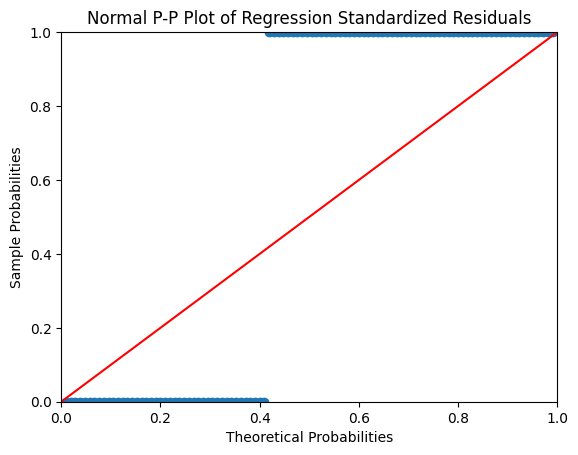

In [ ]:
draw_pp_plot(ipl_model_3,"Normal P-P Plot of Regression Standardized Residuals")
plt.show()

The residual values are obtained by accessing the `.resid` attribute of the fitted linear regression model (`ipl_model_3`). This attribute contains the difference between the actual values (`train_Y`) and the predicted values from the model.

In [ ]:
ipl_model_3_resid_vals=ipl_model_3.resid

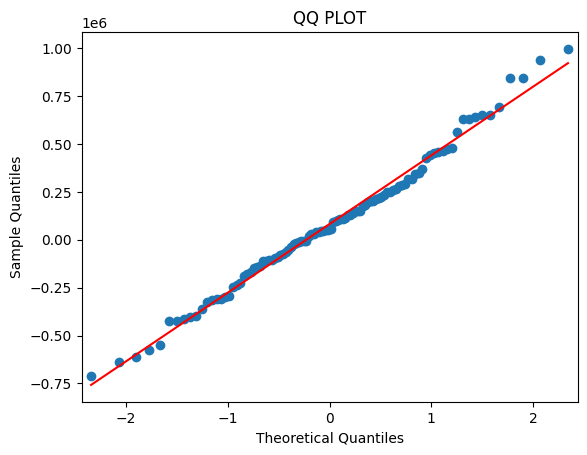

In [ ]:
sm.qqplot(ipl_model_3_resid_vals,line='r')
plt.title('QQ PLOT')
plt.show()

**P-P Plot (Probability-Probability Plot) vs. Q-Q Plot (Quantile-Quantile Plot)**

Both P-P plots and Q-Q plots are graphical tools used to compare the distribution of a dataset to a theoretical distribution (like the normal distribution). However, they differ in how they do this:

*   **P-P Plot:** Compares the cumulative distribution functions (CDFs) of the dataset and the theoretical distribution. It plots the proportion of data points less than or equal to a given value for the dataset against the corresponding proportion for the theoretical distribution. P-P plots are good for assessing how well the tails of the distribution match the theoretical distribution.

*   **Q-Q Plot:** Compares the quantiles of the dataset and the theoretical distribution. It plots the quantiles of the dataset against the quantiles of the theoretical distribution. Q-Q plots are generally more sensitive to differences in the center and tails of the distribution and are widely used to check for normality.

In essence:
*   **P-P plots** compare probabilities (proportions).
*   **Q-Q plots** compare quantiles (values at certain probabilities).

**Residual Plot for Homoscedasticity and Model Specification**

In [ ]:
def get_standardized_values(vals):
  return ((vals-vals.mean())/vals.std())

In [ ]:
def plot_resid_fitted(fitted,resid,title):
  plt.scatter(get_standardized_values(fitted),get_standardized_values(resid))
  plt.title(title)
  plt.xlabel("Standardized predicted values")
  plt.ylabel("Standardized residual values")
  plt.show()

In [ ]:
#train_Y

In [ ]:
#ipl_model_3.fittedvalues

In [ ]:
#ipl_model_3.resid #=AV-PV=(train_Y)-(ipl_model_3.fittedvalues)

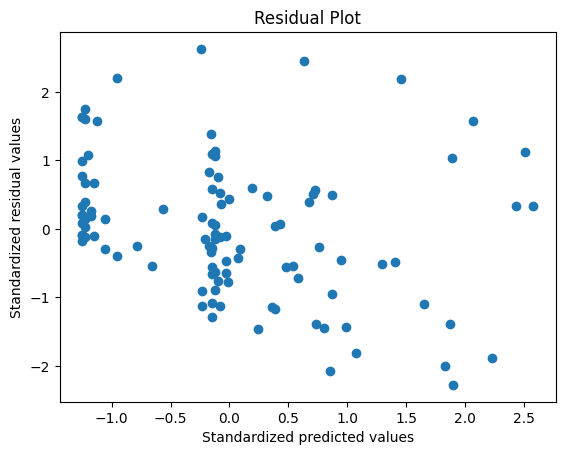

In [ ]:
plot_resid_fitted(ipl_model_3.fittedvalues,
                  ipl_model_3.resid,
                  "Residual Plot")

The `fittedvalues` are a standard attribute of the results object returned by the `fit()` method of a `statsmodels.api.OLS` model. After the model is trained on the data, `ipl_model_3.fittedvalues` directly provides the predicted values for the observations in the training set. These predictions are calculated by the model using the learned coefficients and the corresponding input features (`train_X`).

# **Detecting Influencers**

In [ ]:
k=train_X.shape[1] # no of columns

In [ ]:
n=train_X.shape[0] # no of rows

In [ ]:
print("Number of variables: ",k," and number of Observations: ",n)

Number of variables:  4  and number of Observations:  104


In [ ]:
leverage_cutoff=3*((k+1)/n)
print("cutoff leverage value: ",np.round(leverage_cutoff,3))

cutoff leverage value:  0.144


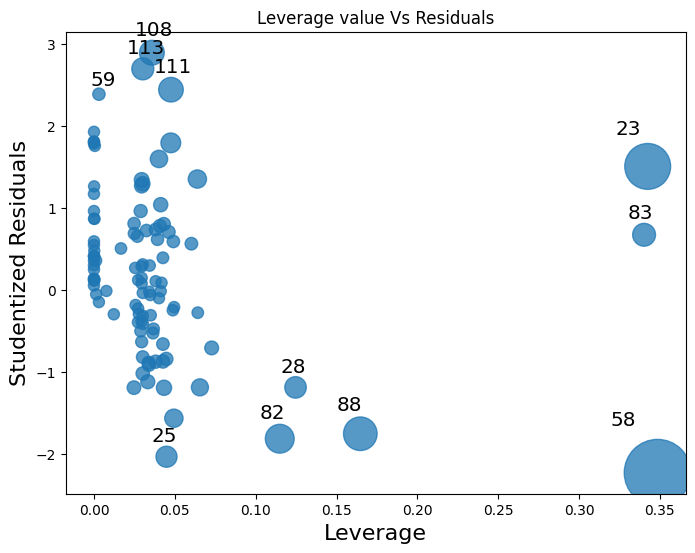

In [ ]:
from statsmodels.graphics.regressionplots import influence_plot
fig, ax=plt.subplots(figsize=(8,6))
#print('fig: ',fig)
#print('ax: ',ax)
influence_plot(ipl_model_3,ax=ax)
plt.title("Leverage value Vs Residuals")
plt.show()

In [ ]:
ipl_auction_df[ipl_auction_df.index.isin([23,58,83])]

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
23,24,"Flintoff, A",2,ENG,CSK,Allrounder,3845,226,3394,88.82,...,116.98,2,105,2,52.50,9.55,33.00,2009,950000,1550000
58,59,"Mascarenhas, AD",2,ENG,RR+,Allrounder,0,0,245,95.33,...,101.37,1,331,19,17.42,7.01,14.95,2011,100000,100000
83,84,"Pietersen, KP",2,ENG,RCB+,Batsman,6654,5,4184,86.76,...,141.20,30,215,7,30.71,7.41,24.86,2009,1350000,1550000


In [ ]:
ipl_model_3.resid

,0
70,650000.000000
78,-292890.253821
47,-104749.617741
0,50000.000000
12,-65630.763652
...,...
71,247990.892090
106,316362.165574
14,-398852.293147
92,216362.165574


In [ ]:
ipl_model_3.resid.loc[[23,58,83]]

,0
23,441165.418481
58,-640471.473042
83,199306.054560


In [ ]:
train_X.iloc[[23,58,83]]

,CAPTAINCY EXP_1,SIXERS,COUNTRY_IND,COUNTRY_ENG
25,1,42,1,0
119,0,37,1,0
1,0,0,0,0


In [ ]:
train_Y.iloc[[23,58,83]]

,SOLD PRICE
25,400000
119,700000
1,50000


In [ ]:
train_X_new=train_X.drop([23,58,83],axis=0)
train_Y_new=train_Y.drop([23,58,83],axis=0)

In [ ]:
train_X_new

,CAPTAINCY EXP_1,SIXERS,COUNTRY_IND,COUNTRY_ENG
70,0,0,0,0
78,0,0,1,0
47,0,28,1,0
0,0,0,0,0
12,0,9,1,0
...,...,...,...,...
71,0,19,1,0
106,0,1,0,0
14,0,36,1,0
92,0,1,0,0


In [ ]:
train_Y_new

,SOLD PRICE
70,650000
78,95000
47,525000
0,50000
12,400000
...,...
71,800000
106,325000
14,300000
92,225000


**Building Model after removing High Influencers**

In [ ]:
#train_X_new
#train_Y_new
ipl_model_new=sm.OLS(train_Y_new,train_X_new).fit()
ipl_model_new.summary2()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.689     
Dependent Variable:     SOLD PRICE       AIC:                         2872.3664 
Date:                   2025-11-21 14:09 BIC:                         2880.2117 
No. Observations:       101              Log-Likelihood:              -1433.2   
Df Model:               3                F-statistic:                 75.50     
Df Residuals:           98               Prob (F-statistic):          2.22e-25  
R-squared (uncentered): 0.698            Scale:                       1.2760e+11
--------------------------------------------------------------------------------
                       Coef.     Std.Err.    t    P>|t|     [0.025      0.975]  
--------------------------------------------------------------------------------
CAPTAINCY EXP_1     334569.0056 74599.3795 4.4849 0.0000 186528.9648 482609.0464
SIXERS                8790.0052  1656.5116 5.3063 0.0000   5502.7118  12077.2986
COUNTRY_IND         390069.6377 62096.7593 6.2816 0.0000 266840.6399 513298.6355
COUNTRY_ENG              0.0000     0.0000    nan    nan      0.0000      0.0000
--------------------------------------------------------------------------------
Omnibus:                   1.880             Durbin-Watson:                2.251
Prob(Omnibus):             0.391             Jarque-Bera (JB):             1.497
Skew:                      0.294             Prob(JB):                     0.473
Kurtosis:                  3.104             Condition No.:                inf  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
[3] The smallest eigenvalue is      0. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

# **Transforming Response Variable**

In [ ]:
train_Y=np.sqrt(train_Y)

In [ ]:
ipl_model_4=sm.OLS(train_Y,train_X).fit()
ipl_model_4.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.741     
Dependent Variable:     SOLD PRICE       AIC:                         1527.9999 
Date:                   2025-11-21 14:09 BIC:                         1538.5775 
No. Observations:       104              Log-Likelihood:              -760.00   
Df Model:               4                F-statistic:                 75.29     
Df Residuals:           100              Prob (F-statistic):          2.63e-29  
R-squared (uncentered): 0.751            Scale:                       1.3550e+05
-----------------------------------------------------------------------------------
                    Coef.      Std.Err.      t       P>|t|      [0.025      0.975] 
-----------------------------------------------------------------------------------
CAPTAINCY EXP_1    417.7575     76.0204    5.4953    0.0000    266.9352    568.5799
SIXERS               8.5338      1.6995    5.0213    0.0000      5.1620     11.9055
COUNTRY_IND        490.7089     63.9238    7.6765    0.0000    363.8860    617.5318
COUNTRY_ENG        563.0261    217.2801    2.5912    0.0110    131.9486    994.1036
--------------------------------------------------------------------------------
Omnibus:                   0.017             Durbin-Watson:                1.879
Prob(Omnibus):             0.992             Jarque-Bera (JB):             0.145
Skew:                      0.005             Prob(JB):                     0.930
Kurtosis:                  2.817             Condition No.:                165  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

<Figure size 800x600 with 0 Axes>

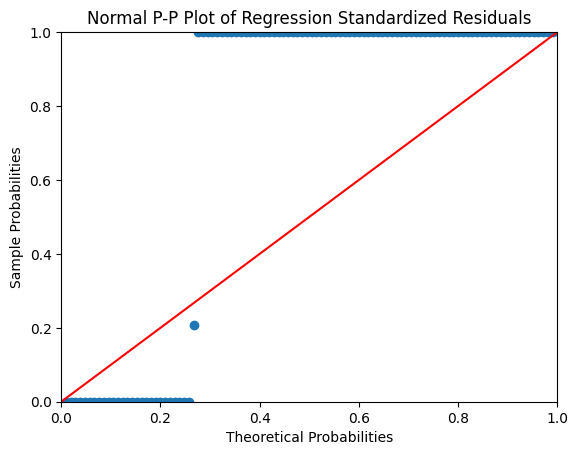

In [ ]:
draw_pp_plot(ipl_model_4,"Normal P-P Plot of Regression Standardized Residuals")

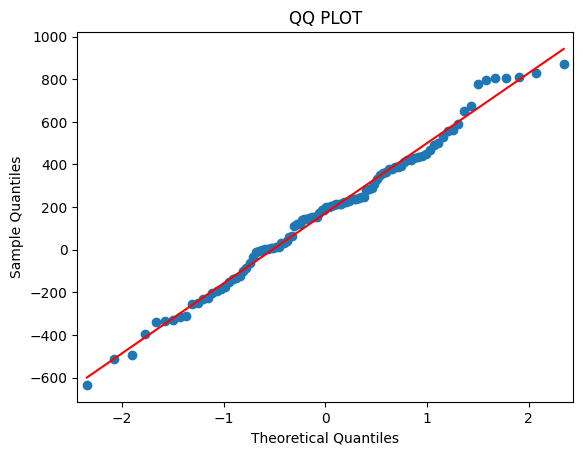

In [ ]:
ipl_model_4_resid_vals=ipl_model_4.resid
sm.qqplot(ipl_model_4_resid_vals,line='r')
plt.title('QQ PLOT')
plt.show()

## **Making Predictions on the Validation Set**

In [ ]:
#test_X

In [ ]:
#test_X.shape

In [ ]:
#test_X[train_X.columns]

In [ ]:
#test_X[train_X.columns].shape

In [ ]:
#ipl_model_4.predict(test_X[train_X.columns])

In [ ]:
pred_Y=np.power(ipl_model_4.predict(test_X[train_X.columns]),2)

# **Measuring RMSE**

In [ ]:
from sklearn import metrics
np.sqrt(metrics.mean_squared_error(pred_Y,test_Y))

np.float64(496151.18122558406)

# **Measuring R-squared Value**

In [ ]:
np.round(metrics.r2_score(pred_Y,test_Y),2)

np.float64(0.44)